In [46]:
import pandas as pd
import bambi as bmb
import numpy as np
import seaborn as sns

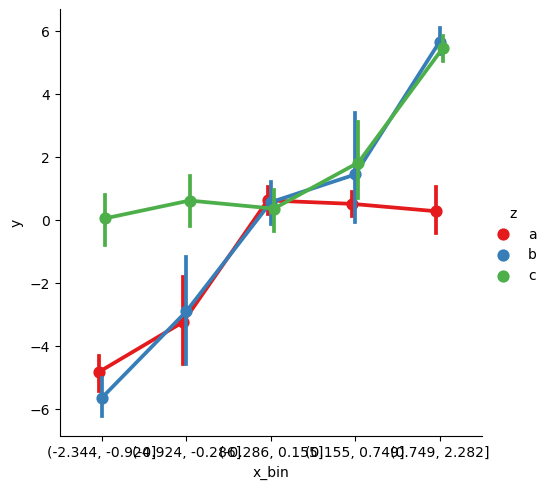

In [61]:
df = pd.DataFrame(np.random.randn(150, 2), columns=['x', 'y'])
df['z'] = np.repeat(['a', 'b', 'c'], 50)


df['y'] = df['y'].where(np.in1d(df['z'], ['a', 'b']) & (df['x'] < -0.5), df['y'] + 5.)
df['y'] = df['y'].where(np.in1d(df['z'], ['b', 'c']) & (df['x'] > 0.5), df['y'] - 5.)
df['y'] = df['y'].where(df['x'] < -.5, df['y'] + .1)


df['x_bin'] = pd.qcut(df['x'], 5)
sns.catplot(x='x_bin', y='y', data=df, kind='point', hue='z', dodge=True, palette='Set1')

df['subject'] = np.repeat(np.arange(10)+1, 15)

In [62]:
model = bmb.Model('y ~ bs(x, df=5)*C(z)+(bs(x, df=5)*C(z)|subject)', data=df)

idata = model.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, Intercept, bs(x, df=5), C(z), bs(x, df=5):C(z), 1|subject_sigma, 1|subject_offset, bs(x, df=5)|subject_sigma, bs(x, df=5)|subject_offset, C(z)|subject_sigma, C(z)|subject_offset, bs(x, df=5):C(z)|subject_sigma, bs(x, df=5):C(z)|subject_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 83 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 630 divergences after tuning. Increase `target_accept` or reparameterize.


# Prediction for illustration

In [63]:
test_x = pd.Series(np.linspace(-2, 2, 100), name='x')
categories = pd.Series(['a', 'b', 'c'], name='z')

test_data = pd.MultiIndex.from_product([test_x, categories]).to_frame()

In [64]:
predictions = model.predict(idata, data=test_data, include_group_specific=False, inplace=False)

In [65]:
predictions = predictions.posterior['y_mean'].to_dataframe().unstack(['chain', 'draw'])
predictions.index = test_data.index

In [66]:
predictions = predictions.stack(['chain', 'draw'])

In [67]:
# This is a 'hack' to get the HDI from the posterior distribution, Seaborn can not do this out-of-the-box
import arviz as az
def get_hdi(d, ci=0.95):
    return az.hdi(d.values, hdi_prob=ci)

(-25.0, 25.0)

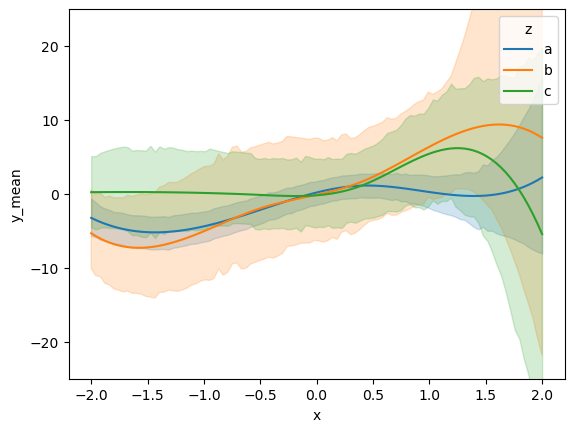

In [70]:
import matplotlib.pyplot as plt
sns.lineplot(data=predictions.reset_index(), x='x', y='y_mean', hue='z', errorbar=get_hdi)
plt.ylim(-25, 25)